# Estatística e Probabilidade

In [2]:
import math
import random
import statistics as st
import matplotlib.pyplot as plt
import numpy as np

# Estilo do plot
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Estatística

Começamos descrevendo um conjunto de dados e observando como um valor extremo pode alterar a leitura do processo.

In [4]:
tempos = [9.8, 10.1, 10.0, 9.9, 10.2, 10.1, 9.7, 15.4]
tempos_sem_outlier = [x for x in tempos if x < 12] # Exemplo de list comprehension

def resumo_numerico(dados):
    dados_ordenados = sorted(dados)
    q1, q2, q3 = np.percentile(dados_ordenados, [25, 50, 75])
    return {
        'media': st.mean(dados),
        'mediana': st.median(dados),
        'q1': q1,
        'q3': q3,
        'desvio_padrao': st.stdev(dados),
        'amplitude': max(dados) - min(dados),
        'iiq': q3 - q1,
    }

print('Com outlier:', resumo_numerico(tempos))
print('Sem outlier:', resumo_numerico(tempos_sem_outlier))

Com outlier: {'media': 10.65, 'mediana': 10.05, 'q1': np.float64(9.875), 'q3': np.float64(10.125), 'desvio_padrao': 1.926506831399404, 'amplitude': 5.700000000000001, 'iiq': np.float64(0.25)}
Sem outlier: {'media': 9.971428571428572, 'mediana': 10.0, 'q1': np.float64(9.850000000000001), 'q3': np.float64(10.1), 'desvio_padrao': 0.1799470821684873, 'amplitude': 0.5, 'iiq': np.float64(0.24999999999999822)}


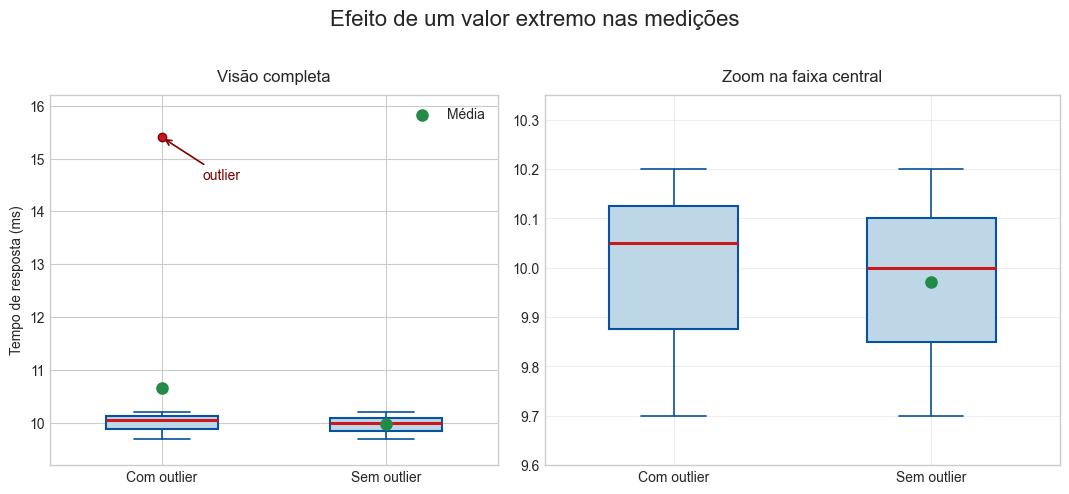

In [5]:
#Ajustando a figura para ficar em formato adequado para os slides
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8), gridspec_kw={'width_ratios': [1.0, 1.15]})
estilo = dict(
    tick_labels=['Com outlier', 'Sem outlier'],
    patch_artist=True,
    widths=0.5,
    boxprops=dict(facecolor='#bdd7e7', edgecolor='#08519c', linewidth=1.5),
    medianprops=dict(color='#cb181d', linewidth=2.2),
    whiskerprops=dict(color='#08519c', linewidth=1.2),
    capprops=dict(color='#08519c', linewidth=1.2),
    flierprops=dict(marker='o', markerfacecolor='#cb181d', markeredgecolor='#7f0000', markersize=6),
)

# Valores médios
medias = [np.mean(tempos), np.mean(tempos_sem_outlier)]

# Box plot com subplot
axes[0].boxplot([tempos, tempos_sem_outlier], **estilo)
axes[0].scatter([1, 2], medias, color='#238b45', s=65, zorder=3, label='Média')
axes[0].annotate('outlier', xy=(1, 15.4), xytext=(1.18, 14.6),
                 arrowprops=dict(arrowstyle='->', color='#7f0000', lw=1.2), color='#7f0000')
axes[0].set_title('Visão completa', pad=10)
axes[0].set_ylabel('Tempo de resposta (ms)')
axes[0].set_ylim(9.2, 16.2)
axes[0].margins(x=0.22)
axes[0].legend(frameon=False, loc='upper right')

axes[1].boxplot([tempos, tempos_sem_outlier], showfliers=False, **{k: v for k, v in estilo.items() if k != 'flierprops'})
axes[1].scatter([1, 2], medias, color='#238b45', s=65, zorder=3)
axes[1].set_title('Zoom na faixa central', pad=10)
axes[1].set_ylim(9.6, 10.35)
axes[1].margins(x=0.22)
axes[1].grid(alpha=0.35)

fig.suptitle('Efeito de um valor extremo nas medições', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

### Como interpretar o boxplot

No boxplot, a linha dentro da caixa representa a mediana. A base e o topo da caixa são, respectivamente, \(Q_1\) e \(Q_3\), os quartis que delimitam os 50% centrais dos dados. A altura da caixa é o intervalo interquartil, isto é, \(IIQ = Q_3 - Q_1\). Os bigodes mostram a extensão dos valores não extremos, e pontos muito afastados aparecem como possíveis *outliers*.

Neste exemplo, o painel com zoom ajuda a enxergar melhor a faixa central, que ficaria comprimida se mostrássemos apenas a escala completa com o valor extremo.

### Correlação

Agora vamos contrastar três situações: correlação positiva, correlação negativa e uma relação forte que não é linear.

In [6]:
potencia = np.array([20, 25, 30, 35, 40, 45])
temperatura = np.array([41, 44, 47, 53, 55, 58])
distancia = np.array([1, 2, 3, 4, 5, 6])
sinal = np.array([90, 84, 77, 70, 65, 58])
x = np.array([-3, -2, -1, 1, 2, 3])
y = x**2

print('Correlação positiva:', round(np.corrcoef(potencia, temperatura)[0, 1], 4))
print('Correlação negativa:', round(np.corrcoef(distancia, sinal)[0, 1], 4))
print('Correlação no caso não linear y = x^2:', round(np.corrcoef(x, y)[0, 1], 4))

Correlação positiva: 0.9917
Correlação negativa: -0.9992
Correlação no caso não linear y = x^2: -0.0


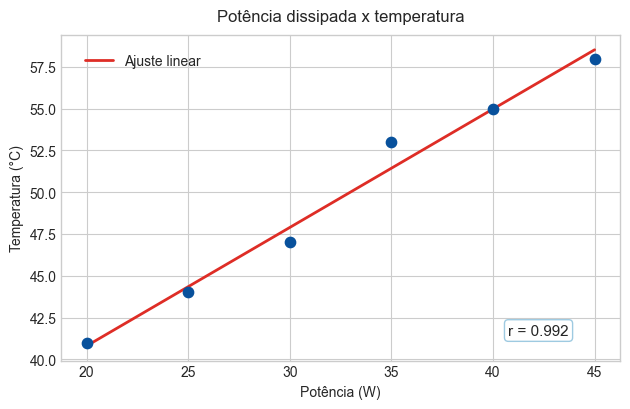

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(potencia, temperatura, color='#08519c', s=55, zorder=3)
coef = np.polyfit(potencia, temperatura, 1)
x_line = np.linspace(potencia.min(), potencia.max(), 100)
ax.plot(x_line, coef[0] * x_line + coef[1], color='#de2d26', linewidth=2.0, label='Ajuste linear')
ax.text(0.80, 0.08, f'r = {np.corrcoef(potencia, temperatura)[0, 1]:.3f}', transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#9ecae1'))
ax.set_title('Potência dissipada x temperatura', pad=10)
ax.set_xlabel('Potência (W)')
ax.set_ylabel('Temperatura (°C)')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.98))
fig.tight_layout()
plt.show()

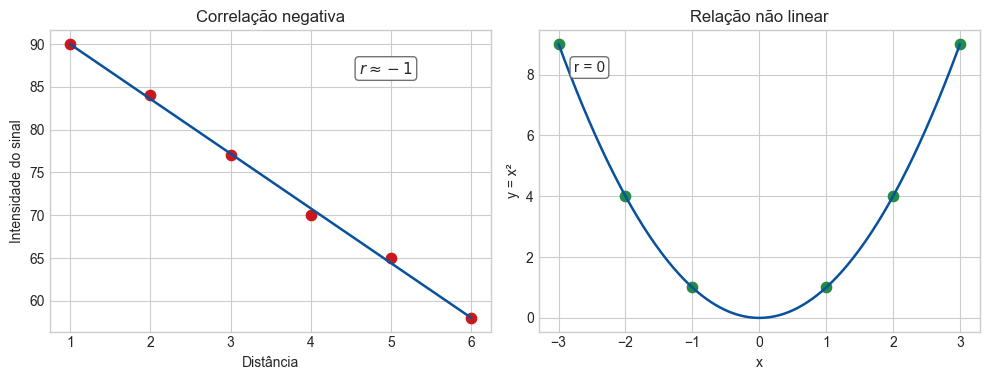

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.9))

axes[0].scatter(distancia, sinal, color='#cb181d', s=55)
coef_neg = np.polyfit(distancia, sinal, 1)
x_neg = np.linspace(distancia.min(), distancia.max(), 100)
axes[0].plot(x_neg, coef_neg[0] * x_neg + coef_neg[1], color='#08519c', linewidth=1.8)
axes[0].set_title('Correlação negativa')
axes[0].set_xlabel('Distância')
axes[0].set_ylabel('Intensidade do sinal')

axes[1].scatter(x, y, color='#238b45', s=55)
x_curve = np.linspace(x.min(), x.max(), 200)
axes[1].plot(x_curve, x_curve**2, color='#08519c', linewidth=1.8)
axes[1].set_title('Relação não linear')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y = x²')

caixa_texto = dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#666666', alpha=0.92)
axes[0].text(0.70, 0.90, r'$r \approx -1$', transform=axes[0].transAxes, fontsize=11,
             ha='left', va='top', bbox=caixa_texto)
axes[1].text(0.08, 0.90, 'r = 0', transform=axes[1].transAxes, fontsize=11,
             ha='left', va='top', bbox=caixa_texto)
fig.tight_layout()
plt.show()

No primeiro gráfico, a tendência linear é clara. No segundo, vemos dois alertas didáticos: um caso com associação negativa e outro em que há padrão forte, mas a correlação linear de Pearson não o descreve bem.

## Correlações espúrias

Um bom antídoto contra interpretações ingênuas é olhar exemplos absurdos, mas reais do ponto de vista numérico. O site [*Spurious Correlations*](https://www.tylervigen.com/spurious-correlations), de Tyler Vigen, reúne pares de séries temporais que se parecem muito correlacionadas e ainda assim não têm conexão causal plausível.

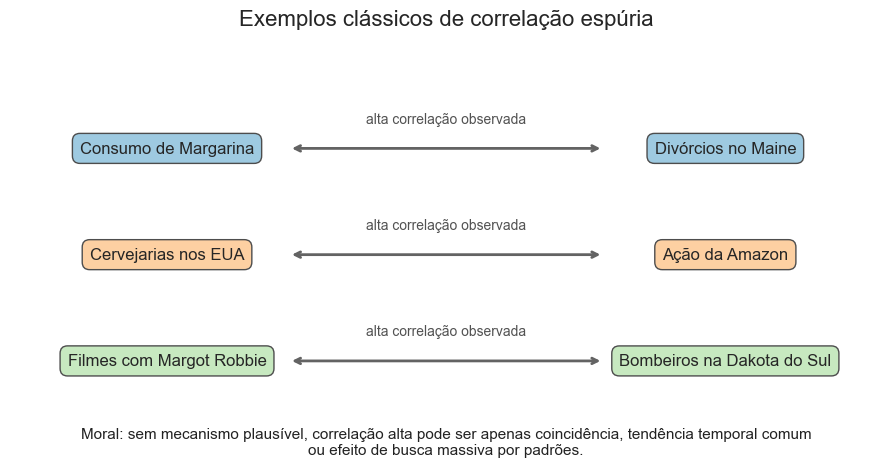

In [9]:
fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.axis('off')
ax.set_title('Exemplos clássicos de correlação espúria', fontsize=16, pad=18)

caixas = [
    ('Consumo de Margarina', 'Divórcios no Maine', '#9ecae1'),
    ('Cervejarias nos EUA', 'Ação da Amazon', '#fdd0a2'),
    ('Filmes com Margot Robbie', 'Bombeiros na Dakota do Sul', '#c7e9c0'),
]

ys = [0.76, 0.50, 0.24]
for (esq, dir_, cor), y0 in zip(caixas, ys):
    ax.text(0.18, y0, esq, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.45', facecolor=cor, edgecolor='#4d4d4d'))
    ax.text(0.82, y0, dir_, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.45', facecolor=cor, edgecolor='#4d4d4d'))
    ax.annotate('', xy=(0.68, y0), xytext=(0.32, y0),
                arrowprops=dict(arrowstyle='<->', lw=2.0, color='#636363'))
    ax.text(0.50, y0 + 0.055, 'alta correlação observada', ha='center', va='bottom', fontsize=10, color='#525252')

ax.text(0.5, 0.04,
        'Moral: sem mecanismo plausível, correlação alta pode ser apenas coincidência, tendência temporal comum\nou efeito de busca massiva por padrões.',
        ha='center', va='center', fontsize=11, color='#222222')

fig.tight_layout()
plt.show()

Esses exemplos são úteis porque treinam o olhar crítico. Um coeficiente alto pode surgir por tendência temporal compartilhada, baixo número de observações, eixos que exageram o efeito ou variáveis de confusão.

### O paradoxo de Simpson

O paradoxo de Simpson ocorre quando uma tendência observada dentro de todos os subgrupos desaparece ou se inverte depois que os dados são agregados.

Didaticamente, a melhor forma de ler esse fenômeno é separar duas perguntas:

- O que acontece quando comparamos casos sob a mesma condição?
- O que acontece quando misturamos condições com dificuldades diferentes?

No exemplo abaixo, a variável de contexto será o nível de ruído de uma bancada de testes eletrônicos.

In [10]:
cenarios = {
    'Baixo ruído': {'A': (91, 100), 'B': (228, 260)},
    'Alto ruído': {'A': (59, 100), 'B': (21, 40)},
}

nomes_grupos = list(cenarios.keys())
taxas_a = [cenarios[g]['A'][0] / cenarios[g]['A'][1] for g in nomes_grupos]
taxas_b = [cenarios[g]['B'][0] / cenarios[g]['B'][1] for g in nomes_grupos]

total_a = sum(cenarios[g]['A'][0] for g in nomes_grupos) / sum(cenarios[g]['A'][1] for g in nomes_grupos)
total_b = sum(cenarios[g]['B'][0] for g in nomes_grupos) / sum(cenarios[g]['B'][1] for g in nomes_grupos)

print('Taxas por cenário:')
for nome, taxa_a, taxa_b in zip(nomes_grupos, taxas_a, taxas_b):
    print(f'{nome}: A = {taxa_a:.3f}, B = {taxa_b:.3f}')
print(f'Taxa agregada A: {total_a:.3f}')
print(f'Taxa agregada B: {total_b:.3f}')

Taxas por cenário:
Baixo ruído: A = 0.910, B = 0.877
Alto ruído: A = 0.590, B = 0.525
Taxa agregada A: 0.750
Taxa agregada B: 0.830


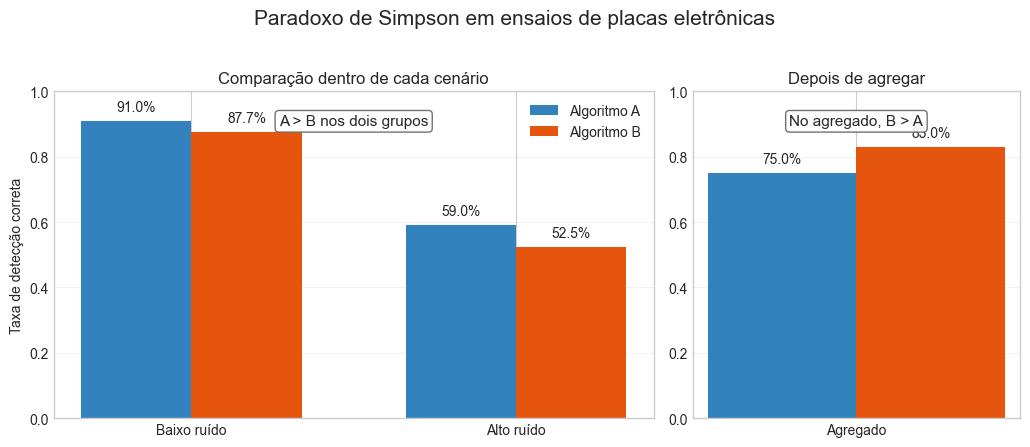

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3), gridspec_kw={'width_ratios': [2.2, 1.2]})
largura = 0.34
pos_grupos = np.arange(len(nomes_grupos))

axes[0].bar(pos_grupos - largura/2, taxas_a, largura, label='Algoritmo A', color='#3182bd')
axes[0].bar(pos_grupos + largura/2, taxas_b, largura, label='Algoritmo B', color='#e6550d')
axes[0].set_xticks(pos_grupos)
axes[0].set_xticklabels(nomes_grupos)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel('Taxa de detecção correta')
axes[0].set_title('Comparação dentro de cada cenário')
axes[0].legend(frameon=False, loc='upper right')
axes[0].grid(axis='y', alpha=0.25)

for i, (ta, tb) in enumerate(zip(taxas_a, taxas_b)):
    axes[0].text(i - largura/2, ta + 0.03, f'{100*ta:.1f}%', ha='center', fontsize=10)
    axes[0].text(i + largura/2, tb + 0.03, f'{100*tb:.1f}%', ha='center', fontsize=10)

axes[0].text(0.5, 0.93, 'A > B nos dois grupos', transform=axes[0].transAxes,
             ha='center', va='top', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#666666', alpha=0.92))

axes[1].bar([0 - largura/2], [total_a], largura, color='#3182bd')
axes[1].bar([0 + largura/2], [total_b], largura, color='#e6550d')
axes[1].set_xticks([0])
axes[1].set_xticklabels(['Agregado'])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('Depois de agregar')
axes[1].grid(axis='y', alpha=0.25)
axes[1].text(-largura/2, total_a + 0.03, f'{100*total_a:.1f}%', ha='center', fontsize=10)
axes[1].text(largura/2, total_b + 0.03, f'{100*total_b:.1f}%', ha='center', fontsize=10)
axes[1].text(0.5, 0.93, 'No agregado, B > A', transform=axes[1].transAxes,
             ha='center', va='top', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#666666', alpha=0.92))

fig.suptitle('Paradoxo de Simpson em ensaios de placas eletrônicas', fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

A interpretação correta é esta:

- Se a pergunta é qual algoritmo funciona melhor sob a mesma condição de ruído, devemos comparar linha por linha.
- Nessas comparações justas, o algoritmo A é melhor em ambos os cenários.
- A inversão aparece porque o algoritmo B concentra muito mais testes no cenário fácil, de baixo ruído.
- Assim, a taxa agregada não resume apenas desempenho: ela também incorpora a distribuição desigual entre casos fáceis e difíceis.

### Onde isso aparece em Machine Learning

Em ML, o mesmo problema surge quando avaliamos modelos apenas por uma métrica global, como acurácia total. Um modelo pode parecer superior porque recebeu mais exemplos de uma classe fácil, de um lote menos ruidoso ou de um subgrupo majoritário.

Por isso, em problemas de classificação e inspeção automática, é boa prática reportar métricas por subgrupo, por classe e por condição operacional.

## 2. Probabilidade

### Probabilidade condicional

Vamos simular o problema: qual é a probabilidade de os dois dados mostrarem o mesmo valor, dado que a soma foi 8?

In [12]:
n = 1_000_000
pares = [(random.randint(1, 6), random.randint(1, 6)) for _ in range(n)]

soma_oito = [p for p in pares if sum(p) == 8]
dois_iguais = [p for p in soma_oito if p[0] == p[1]]


estimativa = len(dois_iguais) / len(soma_oito)
print('Estimativa por simulação:', round(estimativa, 4))
print('Valor teórico esperado:', 1/5)

resultados = ['diferentes', 'iguais']
contagens = [len(soma_oito) - len(dois_iguais), len(dois_iguais)]

Estimativa por simulação: 0.2008
Valor teórico esperado: 0.2


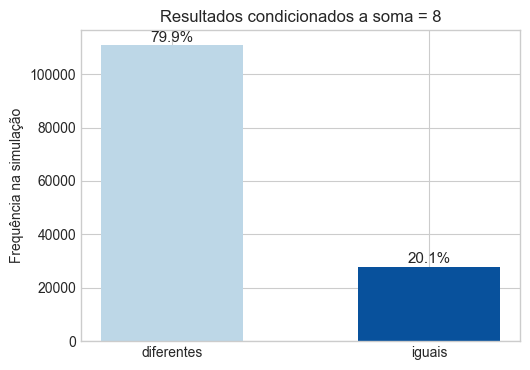

In [13]:
fig, ax = plt.subplots(figsize=(5.4, 3.8))
bars = ax.bar(resultados, contagens, color=['#bdd7e7', '#08519c'], width=0.55)
proporcoes = [c / sum(contagens) for c in contagens]
for bar, prop in zip(bars, proporcoes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{prop:.1%}', ha='center', va='bottom', fontsize=11)
ax.set_title('Resultados condicionados a soma = 8')
ax.set_ylabel('Frequência na simulação')
fig.tight_layout()
plt.show()

O evento condicionado reduz o espaço amostral. Depois dessa redução, apenas uma pequena parte dos casos restantes corresponde a dados iguais.

### Teorema de Bayes

Usaremos o mesmo cenário da apresentação: um teste automático detecta defeitos em placas.

In [14]:
taxa_base = 0.02
sensibilidade = 0.95
falso_positivo = 0.04

numerador = sensibilidade * taxa_base
denominador = numerador + falso_positivo * (1 - taxa_base)
posterior = numerador / denominador

print('P(defeituosa | positivo) =', round(posterior, 4))

n_placas = 200000
defeituosas = np.random.rand(n_placas) < taxa_base
teste_positivo = np.where(
    defeituosas,
    np.random.rand(n_placas) < sensibilidade,
    np.random.rand(n_placas) < falso_positivo
)

verdadeiros_positivos = np.sum(defeituosas & teste_positivo)
falsos_positivos = np.sum((~defeituosas) & teste_positivo)
print('Simulação:', round(verdadeiros_positivos / (verdadeiros_positivos + falsos_positivos), 4))

P(defeituosa | positivo) = 0.3265
Simulação: 0.3226


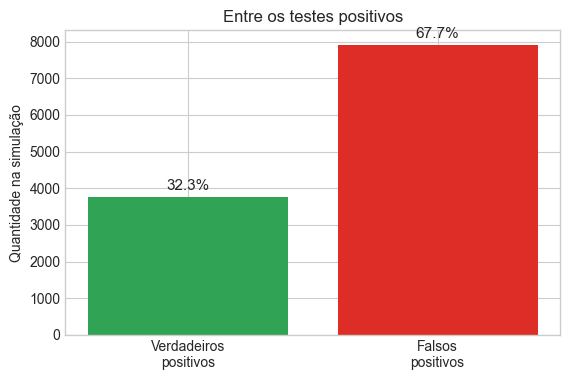

In [15]:
fig, ax = plt.subplots(figsize=(5.8, 3.9))
ax.bar(['Verdadeiros\npositivos', 'Falsos\npositivos'],
       [verdadeiros_positivos, falsos_positivos],
       color=['#31a354', '#de2d26'])
total_pos = verdadeiros_positivos + falsos_positivos
ax.text(0, verdadeiros_positivos + 180, f'{verdadeiros_positivos/total_pos:.1%}', ha='center', fontsize=11)
ax.text(1, falsos_positivos + 180, f'{falsos_positivos/total_pos:.1%}', ha='center', fontsize=11)
ax.set_title('Entre os testes positivos')
ax.set_ylabel('Quantidade na simulação')
fig.tight_layout()
plt.show()

A taxa base baixa faz diferença: mesmo um teste bom ainda produz muitos positivos em placas boas, porque elas são maioria.

### Variáveis aleatórias, distribuições contínuas e normal

Uma curva normal é útil para modelar erros de medição e ruídos. Vamos comparar duas curvas com a mesma média e desvios padrão diferentes.

### Função distribuição acumulada (CDF)

Além da densidade, é importante conhecer a função distribuição acumulada:

\[
F(x) = P(X \leq x)
\]

A CDF informa quanta probabilidade já foi acumulada até um ponto. Em variáveis contínuas, ela cresce de 0 até 1 e corresponde à área acumulada sob a curva de densidade.

In [20]:
from statistics import NormalDist

normal_padrao = NormalDist(mu=0, sigma=1)
valor_cdf = normal_padrao.cdf(0)
print('P(Z <= 1.0) =', valor_cdf)

P(Z <= 1.0) = 0.5


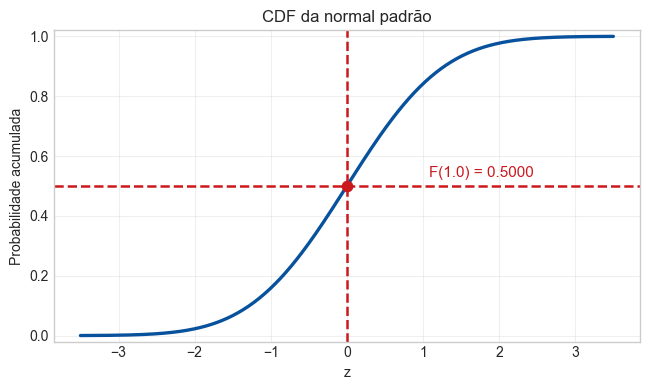

In [21]:
x_cdf = np.linspace(-3.5, 3.5, 400)
cdf_vals = np.array([normal_padrao.cdf(v) for v in x_cdf])

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(x_cdf, cdf_vals, color='#08519c', linewidth=2.4)
ax.axvline(0, color='#cb181d', linestyle='--', linewidth=1.8)
ax.axhline(valor_cdf, color='#cb181d', linestyle='--', linewidth=1.8)
ax.scatter([0], [valor_cdf], color='#cb181d', s=55, zorder=3)
ax.text(1.08, valor_cdf + 0.03, f'F(1.0) = {valor_cdf:.4f}', color='#cb181d', fontsize=11)
ax.set_title('CDF da normal padrão')
ax.set_xlabel('z')
ax.set_ylabel('Probabilidade acumulada')
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Esse valor é aproximadamente 0,8413. Portanto, na normal padrão, há cerca de 84,13% de probabilidade de observar um valor menor ou igual a 1.

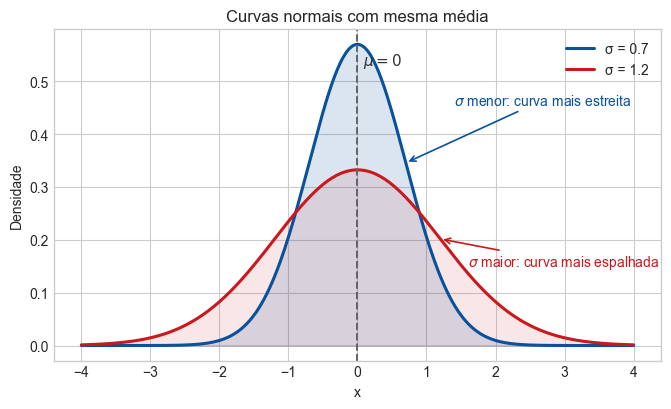

In [33]:
def densidade_normal(x, mu, sigma):
    fator = 1 / (sigma * math.sqrt(2 * math.pi))
    expoente = -0.5 * ((x - mu) / sigma) ** 2
    return fator * np.exp(expoente)

x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
y1 = densidade_normal(x, 0, 0.7)
y2 = densidade_normal(x, 0, 1.2)
ax.plot(x, y1, label='σ = 0.7', linewidth=2.2, color='#08519c')
ax.plot(x, y2, label='σ = 1.2', linewidth=2.2, color='#cb181d')
ax.fill_between(x, y1, alpha=0.15, color='#08519c')
ax.fill_between(x, y2, alpha=0.10, color='#cb181d')
ax.axvline(0, color='#636363', linestyle='--', linewidth=1.4)
ax.text(0.08, max(y1.max(), y2.max()) * 0.93, '$\\mu = 0$', color='#333333', fontsize=11)
ax.annotate('$\\sigma$ menor: curva mais estreita', xy=(0.7, densidade_normal(0.7, 0, 0.7)),
            xytext=(1.4, y1.max() * 0.8), arrowprops=dict(arrowstyle='->', color='#08519c', lw=1.2),
            color='#08519c', fontsize=10)
ax.annotate('$\\sigma$ maior: curva mais espalhada', xy=(1.2, densidade_normal(1.2, 0, 1.2)),
            xytext=(1.6, y2.max() * 0.45), arrowprops=dict(arrowstyle='->', color='#cb181d', lw=1.2),
            color='#cb181d', fontsize=10)
ax.set_title('Curvas normais com mesma média')
ax.set_xlabel('x')
ax.set_ylabel('Densidade')
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()
plt.show()

Curvas com desvio padrão maior ficam mais espalhadas. Em medições, isso significa maior incerteza e maior variação dos valores observados.

### Teorema do limite central

Agora vamos comparar uma distribuição original assimétrica com a distribuição das médias de várias amostras.

In [34]:
originais = np.random.exponential(scale=5, size=50_000)
medias = np.array(
    [np.mean(np.random.exponential(scale=5, size=300)) for _ in range(1000)]
                 )

print('Média dos dados originais:', round(originais.mean(), 4))
print('Média das médias amostrais:', round(medias.mean(), 4))
print('Desvio padrão dos dados originais:', round(originais.std(), 4))
print('Desvio padrão das médias amostrais:', round(medias.std(), 4))

Média dos dados originais: 4.9764
Média das médias amostrais: 5.0086
Desvio padrão dos dados originais: 4.9919
Desvio padrão das médias amostrais: 0.2993


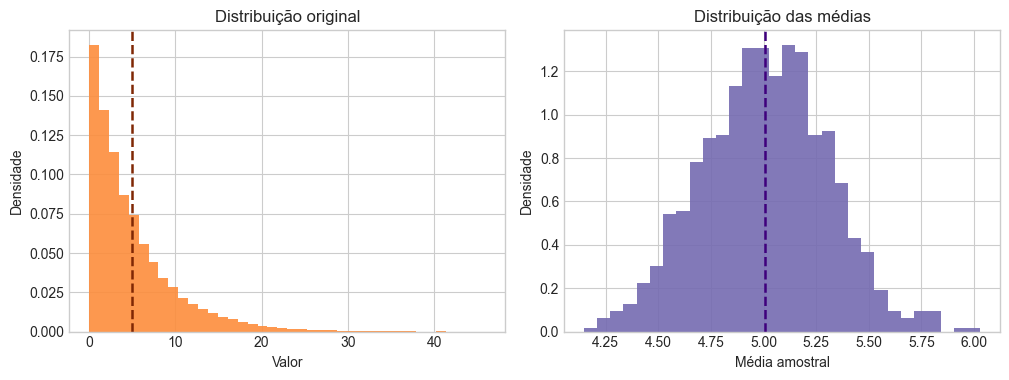

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

axes[0].hist(originais, bins=40, color='#fd8d3c', alpha=0.9, density=True)
axes[0].set_title('Distribuição original')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Densidade')
axes[0].axvline(originais.mean(), color='#7f2704', linestyle='--', linewidth=1.8)

axes[1].hist(medias, bins=30, color='#756bb1', alpha=0.9, density=True)
axes[1].set_title('Distribuição das médias')
axes[1].set_xlabel('Média amostral')
axes[1].set_ylabel('Densidade')
axes[1].axvline(medias.mean(), color='#3f007d', linestyle='--', linewidth=1.8)

fig.tight_layout()
plt.show()

A distribuição original é bastante assimétrica. Já a distribuição das médias fica mais concentrada e mais próxima da forma normal, ilustrando o teorema do limite central.

## Materiais adicionais

Sugestões para continuar estudando:
- alterar os conjuntos de dados e observar o efeito sobre média, mediana e desvio padrão;
- criar exemplos próprios de correlação espúria ou não linear;
- variar a taxa base no exemplo de Bayes e comparar os resultados;
- repetir a simulação do limite central com distribuições uniforme, binomial e lognormal;
- revisar os capítulos 5 e 6 de *Data Science do Zero* com o notebook ao lado.